### Install Kaggle Library

This cell installs the Kaggle library, which is necessary for downloading datasets from Kaggle.

In [8]:
!pip install -q kaggle

### Upload Kaggle API Credentials

This cell prompts you to upload your `kaggle.json` file, which contains your API key for authenticating with Kaggle. Make sure to upload the correct file.

In [9]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"akshatranjan25","key":"5e061e15a39694ea6e7fb8a8e284d228"}'}

### Install Required Libraries and Import Dependencies

This cell installs all necessary Python packages, including `tensorflow`, `gradio`, and `matplotlib`, and then imports them for subsequent steps in the notebook.

In [10]:
# Required packages
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib

# Python imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Download and Extract Dataset from Kaggle

This cell removes any existing dataset, sets up Kaggle authentication using the uploaded `kaggle.json`, and then downloads and extracts the 'new-plant-diseases-dataset' for use in the model.

In [11]:
!rm -rf /content/new-plant-diseases-dataset.zip
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#If dataset not downloaded yet, download & unzip (comment out if already present)
if not os.path.exists("/content/new-plant-diseases-dataset"):
  !kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
  !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset
#Confirm dataset presence (small print)
!ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.69G/2.70G [01:23<00:00, 254MB/s]
100% 2.70G/2.70G [01:23<00:00, 34.5MB/s]
total 20K
drwxr-xr-x 5 root root 4.0K Mar  8 19:58 .
drwxr-xr-x 1 root root 4.0K Mar  8 19:57 ..
drwxr-xr-x 3 root root 4.0K Mar  8 19:57 new plant diseases dataset(augmented)
drwxr-xr-x 3 root root 4.0K Mar  8 19:57 New Plant Diseases Dataset(Augmented)
drwxr-xr-x 3 root root 4.0K Mar  8 19:58 test


### Define Configuration Parameters and Dataset Paths

This cell sets up global configuration parameters such as image dimensions, batch size, number of training epochs, and a random seed. It also defines and verifies the paths to the training and validation directories.

In [12]:
# User / experiment configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
N_LAST_LAYERS = 10  # Unfreeze last 10 layers for fine-tuning
SEED = 1337

# Dataset paths
train_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Verify paths exist
for p in [train_dir, valid_dir]:
    if not os.path.exists(p):
        print(f"ERROR: path not found: {p}")
        sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)

train_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


### Visualize Sample Images from the Dataset

This cell defines and calls a function to display random sample images from different classes within the training dataset, offering a visual inspection of the data.

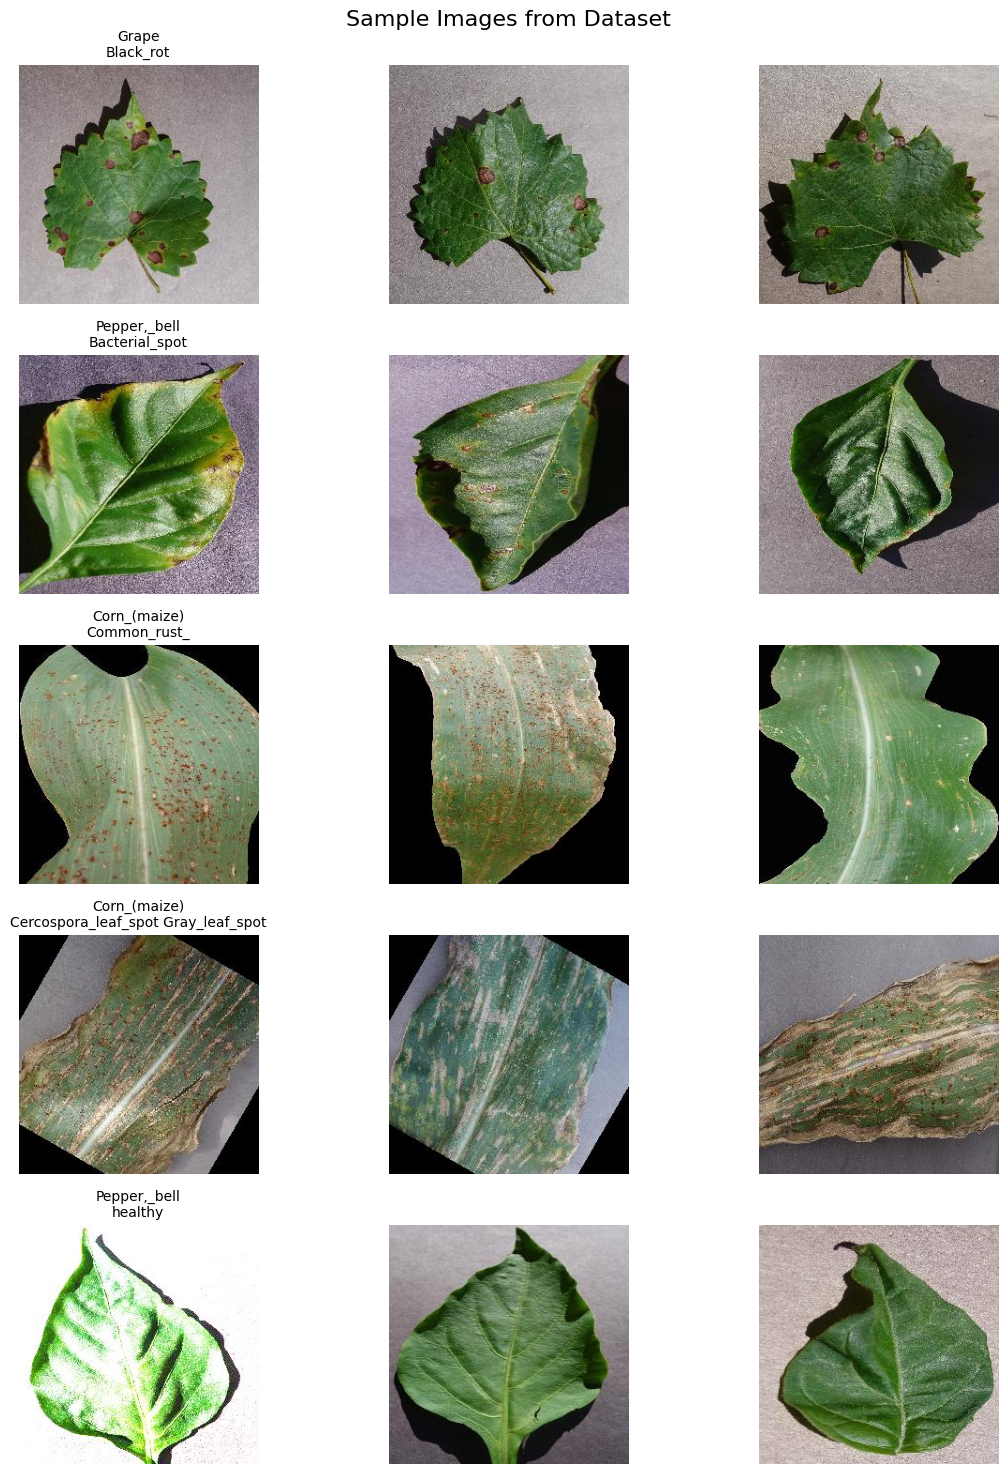

In [13]:
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Function to display random samples from each class
def show_sample_images(base_path, num_classes=5, images_per_class=3):
    """Display random sample images from the dataset"""
    class_names = os.listdir(base_path)
    random_classes = random.sample(class_names, min(num_classes, len(class_names)))

    fig, axes = plt.subplots(num_classes, images_per_class,
                             figsize=(12, 3*num_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16)

    for i, class_name in enumerate(random_classes):
        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        random_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(random_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.replace('___', '\n'), fontsize=10)

    plt.tight_layout()
    plt.show()

# To run the visualization, call the function:
show_sample_images(train_dir)

### Analyze Dataset Distribution

This cell defines a function to count the total images and images per class, then applies it to both the training and validation datasets to display their composition and class distribution.

In [29]:
# Count images in each split
def count_images(directory):
    """Count total images and images per class"""
    total_images = 0
    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    return total_images, class_counts

# Get statistics
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(valid_dir)

print(f"Training images: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")
print(f"\nClass distribution (38):")
for i, (class_name, count) in enumerate(list(train_counts.items())[:]):
    print(f"  {class_name}: {count} images")

Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (38):
  Strawberry___Leaf_scorch: 1774 images
  Potato___Early_blight: 1939 images
  Corn_(maize)___healthy: 1859 images
  Pepper,_bell___Bacterial_spot: 1913 images
  Raspberry___healthy: 1781 images
  Peach___healthy: 1728 images
  Tomato___Target_Spot: 1827 images
  Grape___healthy: 1692 images
  Squash___Powdery_mildew: 1736 images
  Corn_(maize)___Northern_Leaf_Blight: 1908 images
  Tomato___Tomato_mosaic_virus: 1790 images
  Apple___Apple_scab: 2016 images
  Tomato___Spider_mites Two-spotted_spider_mite: 1741 images
  Tomato___Leaf_Mold: 1882 images
  Apple___healthy: 2008 images
  Strawberry___healthy: 1824 images
  Potato___healthy: 1824 images
  Tomato___Late_blight: 1851 images
  Orange___Haunglongbing_(Citrus_greening): 2010 images
  Cherry_(including_sour)___Powdery_mildew: 1683 images
  Tomato___healthy: 1926 images
  Blueberry___healthy: 1816 images
  Tomato___Bacterial_spot: 1702 im

### Prepare Data Generators for Training

This cell sets up `ImageDataGenerator` instances for both training and validation datasets. The training generator includes augmentation techniques to enhance model robustness, and both generators preprocess images suitable for the MobileNetV2 model.

In [15]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
#Training data generator with light augmentation
train_datagen = ImageDataGenerator(
  preprocessing_function = preprocess_input,
  horizontal_flip = True,
  rotation_range = 20,
  zoom_range = 0.15,
  width_shift_range = 0.1,
  height_shift_range = 0.1,
  fill_mode = 'reflect'
)
#Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)
#Create data generators
train_gen = train_datagen.flow_from_directory(
  train_dir,
  target_size = IMG_SIZE,
  batch_size = BATCH_SIZE,
  class_mode = 'categorical',
  shuffle = True,
  seed = SEED
)
valid_gen = valid_datagen.flow_from_directory(
valid_dir,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


### Instantiate MobileNetV2 Base Model

This cell initializes the MobileNetV2 model from Keras Applications. It uses pre-trained weights from `imagenet` and excludes the top classification layer, making it ready for adaptation to our specific plant disease classification task. It also determines the number of classes from the `train_gen`.

In [16]:
from tensorflow.keras.applications import MobileNetV2

# 1. Instantiate the MobileNetV2 model as base_model
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# 2. Determine the number of classes from the training generator
NUM_CLASSES = len(train_gen.class_indices)

# 3. Print NUM_CLASSES to verify
print(f'Number of classes detected: {NUM_CLASSES}')
print('MobileNetV2 base model initialized successfully.')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of classes detected: 38
MobileNetV2 base model initialized successfully.


### Construct the Model Architecture

This cell builds the full model by first freezing all layers of the `base_model` then unfreezing the last 10 layers for fine-tuning. It then adds custom top layers, including `GlobalAveragePooling2D`, `Dropout`, and a `Dense` layer with `softmax` activation, to create the final classification model.

In [17]:
# 1. Freeze all layers of the base_model initially
for layer in base_model.layers:
    layer.trainable = False

# 2. Unfreeze the last 10 layers for fine-tuning
if N_LAST_LAYERS > 0:
    for layer in base_model.layers[-N_LAST_LAYERS:]:
        layer.trainable = True

# 3. Build the full model using Functional API
inputs = keras.Input(shape=IMG_SIZE + (3,))
# We use training=False for the base_model so that BatchNorm layers stay in inference mode
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

# 4. Add custom top layers
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# 5. Instantiate the model and display summary
model = keras.Model(inputs, outputs, name='mobilenetv2_plant_classifier')

model.summary()

# Explicitly count and print parameters to verify
trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f'\nTrainable parameters: {trainable_count:,}')
print(f'Non-trainable parameters: {non_trainable_count:,}')

Model: "mobilenetv2_plant_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 1,070,182 (4.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)


Trainable parameters: 1,070,182
Non-trainable parameters: 1,525,504


### Configure Training Callbacks

This cell defines a list of Keras callbacks to enhance the training process. These include `ModelCheckpoint` to save the best model based on validation accuracy, `ReduceLROnPlateau` to dynamically adjust the learning rate, and `EarlyStopping` to halt training if validation loss plateaus, preventing overfitting.

In [19]:
#Define training callbacks
callbacks = [
    #Save best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
      "/content/mobilenetv2_best.keras",
      monitor='val_accuracy',
      save_best_only=True,
      verbose=1
    ),

    #Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
      monitor ='val_loss',
      factor = 0.5,
      patience = 3 ,
      verbose = 1
    ),

    #Stop training if no improvement
    keras.callbacks.EarlyStopping(
      monitor='val loss',
      patience=6,
      restore_best_weights=True,
      verbose=1
    )
]

print("Callbacks configured:")
print(" 1. ModelCheckpoint - Saves best model")
print(" 2. ReduceLROnPlateau - Adjusts learning rate")
print(" 3. EarlyStopping - Prevents overfitting")

Callbacks configured:
 1. ModelCheckpoint - Saves best model
 2. ReduceLROnPlateau - Adjusts learning rate
 3. EarlyStopping - Prevents overfitting


### Inspect Dataset Directory Structure

This cell defines and uses a function to inspect the directory structure of the unzipped dataset. This helps in verifying the actual paths for training and validation data and ensures that the `ImageDataGenerator` can correctly locate the image classes.

In [21]:
import os

# Inspect the directory structure to find where the classes are actually located
def list_structure(startpath, max_depth=3):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        if level < max_depth:
            indent = ' ' * 4 * level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' ' * 4 * (level + 1)
            # Only show first 5 directories to keep output clean
            for d in dirs[:5]:
                print(f'{subindent}{d}/')
            if len(dirs) > 5:
                print(f'{subindent}... ({len(dirs)} folders)')

base_path = '/content/new-plant-diseases-dataset'
print(f'Exploring {base_path}:')
list_structure(base_path)

Exploring /content/new-plant-diseases-dataset:
new-plant-diseases-dataset/
    new plant diseases dataset(augmented)/
    test/
    New Plant Diseases Dataset(Augmented)/
    new plant diseases dataset(augmented)/
        New Plant Diseases Dataset(Augmented)/
        New Plant Diseases Dataset(Augmented)/
            train/
            valid/
    test/
        test/
        test/
    New Plant Diseases Dataset(Augmented)/
        New Plant Diseases Dataset(Augmented)/
        New Plant Diseases Dataset(Augmented)/
            train/
            valid/


### Re-verify Dataset Paths and Recreate Generators

Based on the directory inspection, this cell explicitly sets the correct `train_dir` and `valid_dir` to ensure they point to the actual class folders. It then re-initializes the `ImageDataGenerator` instances and data generators with these verified paths, ensuring that the model can correctly access the dataset.

In [22]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Updated paths based on the directory inspection
train_dir = '/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'

# Re-verify directory existence
for d in [train_dir, valid_dir]:
    if os.path.isdir(d):
        print(f'Confirmed directory: {d}')
        print(f'  Contains {len(os.listdir(d))} class folders.')
    else:
        print(f'Error: {d} is not a valid directory.')

# Redefine Generators with verified paths
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'Final class count: {NUM_CLASSES}')

Confirmed directory: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
  Contains 38 class folders.
Confirmed directory: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid
  Contains 38 class folders.
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Final class count: 38


### Compile and Train the Model

This cell compiles the full model with the Adam optimizer and `categorical_crossentropy` loss, and then initiates the training process. The model is trained for a specified number of epochs using the prepared data generators and the defined callbacks to monitor and improve performance.

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models, callbacks

# 1. Instantiate the MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze all layers and unfreeze the last 10 layers
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# 3. Build the full model using Functional API
inputs = keras.Input(shape=IMG_SIZE + (3,))
# training=False keeps BatchNorm in inference mode
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='plant_disease_mobilenetv2')

# 4. Define training callbacks
checkpoint_cb = callbacks.ModelCheckpoint(
    '/content/mobilenetv2_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# 5. Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train the model
print('Starting model training...')
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb],
    verbose=1
)

print('Training phase completed.')

Starting model training...
Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6645 - loss: 1.2380

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.91555, saving model to /content/mobilenetv2_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 960s 431ms/step - accuracy: 0.6646 - loss: 1.2377 - val_accuracy: 0.9155 - val_loss: 0.2608 - learning_rate: 1.0000e-04
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9197 - loss: 0.2493
Epoch 2: val_accuracy improved from 0.91555 to 0.95231, saving model to /content/mobilenetv2_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 886s 403ms/step - accuracy: 0.9197 - loss: 0.2492 - val_accuracy: 0.9523 - val_loss: 0.1549 - learning_rate: 1.0000e-04
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9384 - loss: 0.1855
Epoch 3: val_accuracy improved from 0.95231 to 0.96455, saving model to /content/mobilenetv2_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 858s 391ms/step - accuracy: 0.9384 - loss: 0.1855 - val_accuracy: 0.9645 - val_loss: 0.1070 - learning_rate: 1.0000e-04
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - ac

### Visualize Training History

This cell plots the training and validation accuracy and loss over the epochs using the `history` object generated during model training. These plots provide a visual representation of the model's learning progress and help identify potential overfitting or underfitting issues.

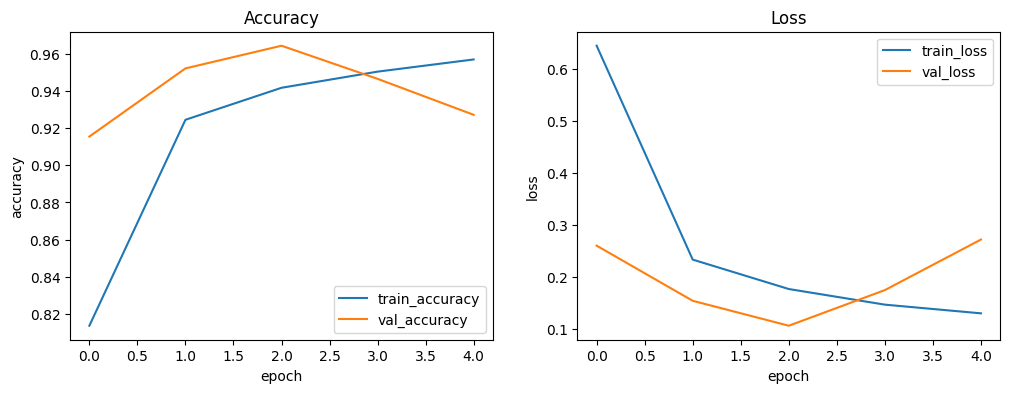

In [24]:
# ---------------- Plot training curves ----------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy',[]), label='train_accuracy')
plt.plot(history.history.get('val_accuracy',[]), label='val_accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss',[]), label='train_loss')
plt.plot(history.history.get('val_loss',[]), label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')
plt.show()

### Evaluate Model Performance on Validation Set

This cell evaluates the trained model's performance on the validation dataset using the `model.evaluate()` method. It outputs the final validation loss and accuracy, providing a quantitative measure of how well the model generalizes to unseen data.

In [25]:
# ---------------- Evaluate ----------------
val_loss, val_acc = model.evaluate(valid_gen)
print(f"Validation loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9762 - loss: 0.0779
Validation loss: 0.1070, accuracy: 0.9645


### Save Model as a .pkl File

This cell saves the trained Keras model as a Python pickle (`.pkl`) file.

In [26]:
import pickle

# Define the path for the .pkl file
pkl_model_path = '/content/mobilenetv2_plant_classifier.pkl'

# Save the model using pickle
with open(pkl_model_path, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved as .pkl file to: {pkl_model_path}")

Model saved as .pkl file to: /content/mobilenetv2_plant_classifier.pkl


### Download the .pkl Model File

This cell initiates the download of the previously saved `.pkl` model file to your local machine, allowing you to use it outside of this Colab environment.

In [28]:
from google.colab import files

# Download the .pkl file
try:
  files.download('/content/mobilenetv2_plant_classifier.pkl')
  print("File download initiated.")
except Exception as e:
  print(f"Error downloading file: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File download initiated.


### Display Class Label to Index Mapping

This cell prints the mapping between the human-readable class labels (e.g., 'Apple___healthy') and their corresponding numerical indices (e.g., 0) as derived from the `train_gen` object. This mapping is crucial for understanding the model's output.

In [30]:
# Display the class indices mapping
print("Class Label to Index Mapping:")
for class_name, index in train_gen.class_indices.items():
    print(f"  {class_name}: {index}")

Class Label to Index Mapping:
  Apple___Apple_scab: 0
  Apple___Black_rot: 1
  Apple___Cedar_apple_rust: 2
  Apple___healthy: 3
  Blueberry___healthy: 4
  Cherry_(including_sour)___Powdery_mildew: 5
  Cherry_(including_sour)___healthy: 6
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 7
  Corn_(maize)___Common_rust_: 8
  Corn_(maize)___Northern_Leaf_Blight: 9
  Corn_(maize)___healthy: 10
  Grape___Black_rot: 11
  Grape___Esca_(Black_Measles): 12
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 13
  Grape___healthy: 14
  Orange___Haunglongbing_(Citrus_greening): 15
  Peach___Bacterial_spot: 16
  Peach___healthy: 17
  Pepper,_bell___Bacterial_spot: 18
  Pepper,_bell___healthy: 19
  Potato___Early_blight: 20
  Potato___Late_blight: 21
  Potato___healthy: 22
  Raspberry___healthy: 23
  Soybean___healthy: 24
  Squash___Powdery_mildew: 25
  Strawberry___Leaf_scorch: 26
  Strawberry___healthy: 27
  Tomato___Bacterial_spot: 28
  Tomato___Early_blight: 29
  Tomato___Late_blight: 30
  Tomato_